In [1]:
# ============================================================
# Step 3 Diagnostic: Does the Fix Change WORST-GROUP ACCURACY,
# or Only Collapse Speed?
#
# THE QUESTION:
#   The kill-test shows present-set renormalization prevents the
#   minority WEIGHT from collapsing. But does that translate into
#   higher minority/worst-group ACCURACY at convergence — the
#   metric papers actually report? Or does the model recover the
#   minority anyway (via interpolation), leaving final accuracy
#   unchanged?
#
#   This determines whether the contribution is:
#     (a) "changes published benchmark accuracy"  [headline], or
#     (b) "prevents premature weight collapse"     [mechanism only]
#   Both are publishable; we need to know which is true.
#
# DESIGN (Fitzpatrick17k, the setup that is known to collapse):
#   - Extract CLIP ViT-L/14 frozen features once.
#   - Groups = skin tone {light, medium, dark} × class {benign,
#     malignant, non-neoplastic}. Minority cell = dark+benign.
#   - Run DRO three ways, IDENTICAL except absent-group handling:
#       1. zerofill        (Sagawa/WILDS convention)
#       2. naive_mask      (SubpopBench convention)
#       3. present_renorm  (the fix)
#   - Track over training: q_min(t), worst-group accuracy,
#     minority-cell accuracy, average accuracy.
#   - Report FINAL worst-group and minority accuracy for each.
#
# DECISIVE OUTPUT (Cell 7):
#   table of {convention -> final worst-group acc, final minority
#   acc, collapse step}. If present_renorm's worst-group acc is
#   substantially higher, Step 3 is the headline.
#
# RUNTIME: ~25 min on T4 (feature extraction ~15, DRO ~10)
# DATASET: nazmusresan/fitzpatrick17k
# ============================================================

!pip install transformers -q

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd, os, json, math, warnings
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from collections import Counter
warnings.filterwarnings('ignore')

SEEDS      = [42, 0, 1]
ETA        = 0.1
THR        = 0.01
MAX_STEPS  = 3000
BATCH      = 64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Question: does present-set renorm raise WORST-GROUP ACCURACY,')
print('          or only prevent weight collapse?')

Device: cuda
Question: does present-set renorm raise WORST-GROUP ACCURACY,
          or only prevent weight collapse?


In [2]:
# ── CELL 2: Locate Fitzpatrick data ───────────────────────────
fitz_csv = None; fitz_img_dir = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv') and 'fitzpatrick' in f.lower():
            fitz_csv = os.path.join(root, f)
    for d in dirs:
        if 'background' in d.lower() or 'removed' in d.lower():
            cand = os.path.join(root, d)
            imgs = [x for x in os.listdir(cand) if x.endswith(('.jpg','.png'))]
            if len(imgs) > 100: fitz_img_dir = cand
if fitz_img_dir is None:
    for root, dirs, files in os.walk('/kaggle/input'):
        imgs = [f for f in files if f.endswith(('.jpg','.png'))]
        if len(imgs) > 1000: fitz_img_dir = root; break
print(f'CSV: {fitz_csv}')
print(f'Images: {fitz_img_dir}')

df = pd.read_csv(fitz_csv)
fitz_col = next((c for c in df.columns if 'fitzpatrick' in c.lower() and 'scale' in c.lower()), None)
if fitz_col is None:
    fitz_col = next((c for c in df.columns if 'fitzpatrick' in c.lower()), None)
label_col = next((c for c in ['three_partition_label','label','condition'] if c in df.columns), None)
id_col = next((c for c in ['md5hash','image_id','filename','image'] if c in df.columns), None)
print(f'fitz_col={fitz_col}  label_col={label_col}  id_col={id_col}')
print(f'Labels: {df[label_col].value_counts().to_dict()}')

# skin groups from Fitzpatrick scale
df = df[df[fitz_col].notna() & (df[fitz_col] > 0)].copy()
df['skin_group'] = df[fitz_col].apply(lambda x: 'light' if x<=2 else 'medium' if x<=4 else 'dark')
print(f'Skin groups: {df["skin_group"].value_counts().to_dict()}')

# image path map
image_files = {}
for f in os.listdir(fitz_img_dir):
    if f.endswith(('.jpg','.png')):
        image_files[f.replace('.jpg','').replace('.png','')] = os.path.join(fitz_img_dir, f)
df['local_path'] = df[id_col].astype(str).map(image_files)
df = df[df['local_path'].notna()].copy()
print(f'Matched {len(df)} images to metadata')

CSV: /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder/fitzpatrick17k (1).csv
Images: /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder/background removed
fitz_col=fitzpatrick_scale  label_col=three_partition_label  id_col=md5hash
Labels: {'non-neoplastic': 12080, 'malignant': 2263, 'benign': 2234}
Skin groups: {'light': 7755, 'medium': 6089, 'dark': 2168}
Matched 16012 images to metadata


In [4]:
# ── CELL 3 (FIXED): Extract CLIP features once ────────────────
print('Loading CLIP ViT-L/14...')
clip_model = CLIPModel.from_pretrained('openai/clip-vit-large-patch14').to(device).eval()
clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-large-patch14')

def extract_clip(paths, bs=32):
    feats = []
    for i in range(0, len(paths), bs):
        batch_imgs = []
        for p in paths[i:i+bs]:
            try: batch_imgs.append(Image.open(p).convert('RGB'))
            except: batch_imgs.append(Image.new('RGB',(224,224)))
        inp = clip_proc(images=batch_imgs, return_tensors='pt').to(device)
        with torch.no_grad():
            out = clip_model.get_image_features(**inp)
        # Handle transformers versions that wrap the output
        if torch.is_tensor(out):
            f = out
        elif hasattr(out, 'image_embeds'):
            f = out.image_embeds
        elif hasattr(out, 'pooler_output'):
            f = out.pooler_output
        else:
            f = out[0]
        feats.append(f.cpu())
        if (i//bs) % 10 == 0: print(f'  {i+len(batch_imgs)}/{len(paths)}')
    return torch.cat(feats)

# Encode labels to integers
label_names = sorted(df[label_col].unique())
label_to_int = {l:i for i,l in enumerate(label_names)}
n_classes = len(label_names)
df['y'] = df[label_col].map(label_to_int)
print(f'Classes ({n_classes}): {label_to_int}')

# Group = skin_group x class
skin_to_int = {'light':0,'medium':1,'dark':2}
df['skin_int'] = df['skin_group'].map(skin_to_int)
df['group'] = df['skin_int'] * n_classes + df['y']
n_groups = 3 * n_classes
print(f'n_groups = {n_groups} (3 skin x {n_classes} class)')

# Cap per skin group for balance/runtime (keep all dark)
MAX_PER_SKIN = 2000
parts = []
for sg in ['light','medium','dark']:
    sub = df[df['skin_group']==sg]
    if sg != 'dark' and len(sub) > MAX_PER_SKIN:
        sub = sub.sample(MAX_PER_SKIN, random_state=42)
    parts.append(sub)
df_use = pd.concat(parts).reset_index(drop=True)
print(f'Using {len(df_use)} images')
print('Group counts:')
group_counts_all = df_use['group'].value_counts().sort_index()
for g in range(n_groups):
    sk = ['light','medium','dark'][g//n_classes]; cl = label_names[g%n_classes]
    print(f'  g={g} ({sk}+{cl}): {group_counts_all.get(g,0)}')

print('\nExtracting CLIP features...')
X = extract_clip(df_use['local_path'].tolist())
y = torch.tensor(df_use['y'].values).long()
g = torch.tensor(df_use['group'].values).long()
torch.save(X,'fitz_clip.pt'); torch.save(y,'fitz_y.pt'); torch.save(g,'fitz_g.pt')
print(f'Features: {X.shape}')

Loading CLIP ViT-L/14...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Classes (3): {'benign': 0, 'malignant': 1, 'non-neoplastic': 2}
n_groups = 9 (3 skin x 3 class)
Using 6168 images
Group counts:
  g=0 (light+benign): 296
  g=1 (light+malignant): 321
  g=2 (light+non-neoplastic): 1383
  g=3 (medium+benign): 268
  g=4 (medium+malignant): 243
  g=5 (medium+non-neoplastic): 1489
  g=6 (dark+benign): 203
  g=7 (dark+malignant): 208
  g=8 (dark+non-neoplastic): 1757

Extracting CLIP features...
  32/6168
  352/6168
  672/6168
  992/6168
  1312/6168
  1632/6168
  1952/6168
  2272/6168
  2592/6168
  2912/6168
  3232/6168
  3552/6168
  3872/6168
  4192/6168
  4512/6168
  4832/6168
  5152/6168
  5472/6168
  5792/6168
  6112/6168
Features: torch.Size([6168, 768])


In [5]:
# ── CELL 4: Train/test split + minority identification ────────
X = torch.load('fitz_clip.pt').float()
y = torch.load('fitz_y.pt').long()
g = torch.load('fitz_g.pt').long()
embed_dim = X.shape[1]

# Stratified-ish split by group (70/30), keep all groups in both
torch.manual_seed(42); np.random.seed(42)
train_idx, test_idx = [], []
for grp in range(n_groups):
    idx = torch.where(g==grp)[0].numpy()
    np.random.shuffle(idx)
    cut = int(0.7*len(idx))
    train_idx += idx[:cut].tolist()
    test_idx  += idx[cut:].tolist()
train_idx = torch.tensor(train_idx); test_idx = torch.tensor(test_idx)

X_tr, y_tr, g_tr = X[train_idx], y[train_idx], g[train_idx]
X_te, y_te, g_te = X[test_idx], y[test_idx], g[test_idx]

# Minority cell = smallest TRAIN group with >=5 test examples
train_counts = {gg: int((g_tr==gg).sum()) for gg in range(n_groups)}
test_counts  = {gg: int((g_te==gg).sum()) for gg in range(n_groups)}
valid = {gg:c for gg,c in train_counts.items() if test_counts.get(gg,0)>=5 and c>=1}
MINORITY_G = min(valid, key=valid.get)
f_min = train_counts[MINORITY_G]/len(g_tr)
pi_min = 1-(1-f_min)**BATCH
sk = ['light','medium','dark'][MINORITY_G//n_classes]; cl = label_names[MINORITY_G%n_classes]
print(f'Train: {X_tr.shape}  Test: {X_te.shape}')
print(f'Minority cell: g={MINORITY_G} ({sk}+{cl})')
print(f'  train n={train_counts[MINORITY_G]}, test n={test_counts[MINORITY_G]}')
print(f'  f={f_min:.5f}  π={pi_min:.3f}  (absent {(1-pi_min)*100:.1f}% of batches)')

Train: torch.Size([4314, 768])  Test: torch.Size([1854, 768])
Minority cell: g=6 (dark+benign)
  train n=142, test n=61
  f=0.03292  π=0.883  (absent 11.7% of batches)


In [6]:
# ── CELL 5: DRO runner with three conventions + accuracy tracking ──
class LinCls(nn.Module):
    def __init__(self, d, k): super().__init__(); self.fc=nn.Linear(d,k)
    def forward(self,x): return self.fc(x)

def eval_accuracies(model, X_te, y_te, g_te):
    """Return (avg_acc, worst_group_acc, minority_acc, per_group_acc dict)."""
    model.eval()
    with torch.no_grad():
        pred = model(X_te.to(device)).argmax(1).cpu()
    correct = (pred==y_te)
    per_group = {}
    for grp in range(n_groups):
        m = g_te==grp
        if m.sum()>0:
            per_group[grp] = float(correct[m].float().mean())
    avg = float(correct.float().mean())
    worst = min(per_group.values())
    minority = per_group.get(MINORITY_G, float('nan'))
    model.train()
    return avg, worst, minority, per_group

def run_dro(convention, seed=42, eta=ETA, B=BATCH, max_steps=MAX_STEPS, wd=1e-3):
    torch.manual_seed(seed); np.random.seed(seed)
    ds = TensorDataset(X_tr, y_tr, g_tr)
    ld = DataLoader(ds, batch_size=B, shuffle=True, num_workers=0)
    model = LinCls(embed_dim, n_classes).to(device)
    opt = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=wd)
    q = torch.ones(n_groups).to(device)/n_groups
    collapse_step = None; step = 0
    qmin_trace=[]; eval_trace=[]   # eval_trace: (step, avg, worst, minority)

    while step < max_steps:
        for xb,yb,gb in ld:
            if step>=max_steps: break
            xb,yb,gb = xb.to(device),yb.to(device),gb.to(device)
            opt.zero_grad()
            losses = nn.CrossEntropyLoss(reduction='none')(model(xb), yb)
            g_loss = torch.zeros(n_groups).to(device); present=[]
            for gi in range(n_groups):
                m = gb==gi
                if m.sum()>0: g_loss[gi]=losses[m].mean(); present.append(gi)

            if convention=='zerofill':
                # absent groups have g_loss=0; full-simplex renorm
                q = q*torch.exp(eta*g_loss.detach()); q=q/q.sum()
            elif convention=='naive_mask':
                # update only present groups; full-simplex renorm (SubpopBench)
                qn = q.clone()
                for gi in present:
                    qn[gi] = q[gi]*math.exp(eta*float(g_loss[gi]))
                q = qn/qn.sum()
            elif convention=='present_renorm':
                # update present groups; renorm ONLY within present block (the fix)
                if present:
                    pres = torch.tensor(present, device=device)
                    mass_before = q[pres].sum()
                    qn = q.clone()
                    qn[pres] = q[pres]*torch.exp(eta*g_loss[pres].detach())
                    qn[pres] = qn[pres]*mass_before/qn[pres].sum()
                    q = qn

            (q*g_loss).sum().backward(); opt.step(); step+=1
            mq = float(q.min().item()); qmin_trace.append(mq)
            if collapse_step is None and mq<THR: collapse_step=step
            if step % 100 == 0:
                avg,worst,minr,_ = eval_accuracies(model, X_te, y_te, g_te)
                eval_trace.append((step,avg,worst,minr))
    avg,worst,minor,per_group = eval_accuracies(model, X_te, y_te, g_te)
    return {'qmin_trace':qmin_trace,'eval_trace':eval_trace,
            'collapse_step':collapse_step,'final_avg':avg,
            'final_worst':worst,'final_minority':minor,
            'final_per_group':per_group}

print('Runner defined: zerofill | naive_mask | present_renorm')
print('Tracks q_min AND worst-group/minority accuracy over training.')

Runner defined: zerofill | naive_mask | present_renorm
Tracks q_min AND worst-group/minority accuracy over training.


In [7]:
# ── CELL 6: Run all three conventions ─────────────────────────
print('='*60)
print('Running 3 conventions x 3 seeds')
print('='*60)
results = {}
for conv in ['zerofill','naive_mask','present_renorm']:
    print(f'\n--- {conv} ---')
    runs=[]
    for seed in SEEDS:
        r = run_dro(conv, seed=seed)
        runs.append(r)
        cs = r['collapse_step']
        print(f'  seed {seed}: collapse={cs if cs else ">budget":>6}  '
              f'final worst-grp acc={r["final_worst"]:.3f}  '
              f'minority acc={r["final_minority"]:.3f}  '
              f'avg acc={r["final_avg"]:.3f}')
    results[conv]=runs
print('\nDone.')

Running 3 conventions x 3 seeds

--- zerofill ---
  seed 42: collapse=>budget  final worst-grp acc=0.449  minority acc=0.459  avg acc=0.656
  seed 0: collapse=   706  final worst-grp acc=0.333  minority acc=0.443  avg acc=0.657
  seed 1: collapse=   242  final worst-grp acc=0.444  minority acc=0.475  avg acc=0.642

--- naive_mask ---
  seed 42: collapse=>budget  final worst-grp acc=0.449  minority acc=0.459  avg acc=0.656
  seed 0: collapse=   706  final worst-grp acc=0.333  minority acc=0.443  avg acc=0.657
  seed 1: collapse=   242  final worst-grp acc=0.444  minority acc=0.475  avg acc=0.642

--- present_renorm ---
  seed 42: collapse=>budget  final worst-grp acc=0.459  minority acc=0.459  avg acc=0.637
  seed 0: collapse=   430  final worst-grp acc=0.349  minority acc=0.459  avg acc=0.648
  seed 1: collapse=   336  final worst-grp acc=0.476  minority acc=0.541  avg acc=0.633

Done.


DECISIVE RESULT: does the fix change WORST-GROUP ACCURACY?

Convention         Worst-grp acc    Minority acc     Avg acc    Collapse
------------------------------------------------------------------------
zerofill             0.409±0.054     0.459±0.013       0.652     1316 (2/3)
naive_mask           0.409±0.054     0.459±0.013       0.652     1316 (2/3)
present_renorm       0.428±0.056     0.486±0.039       0.639     1256 (2/3)

Δ worst-group acc (present_renorm - zerofill): +0.019
Δ minority acc:                                +0.027

=> MECHANISM-ONLY: the fix prevents WEIGHT collapse but final
   worst-group accuracy is ~unchanged (+1.9%).
   Frame as: artifact affects training dynamics / early stopping
   reliance, not necessarily converged accuracy. Still publishable,
   different claim. (Consistent with interpolation channel recovering
   the minority given enough steps.)


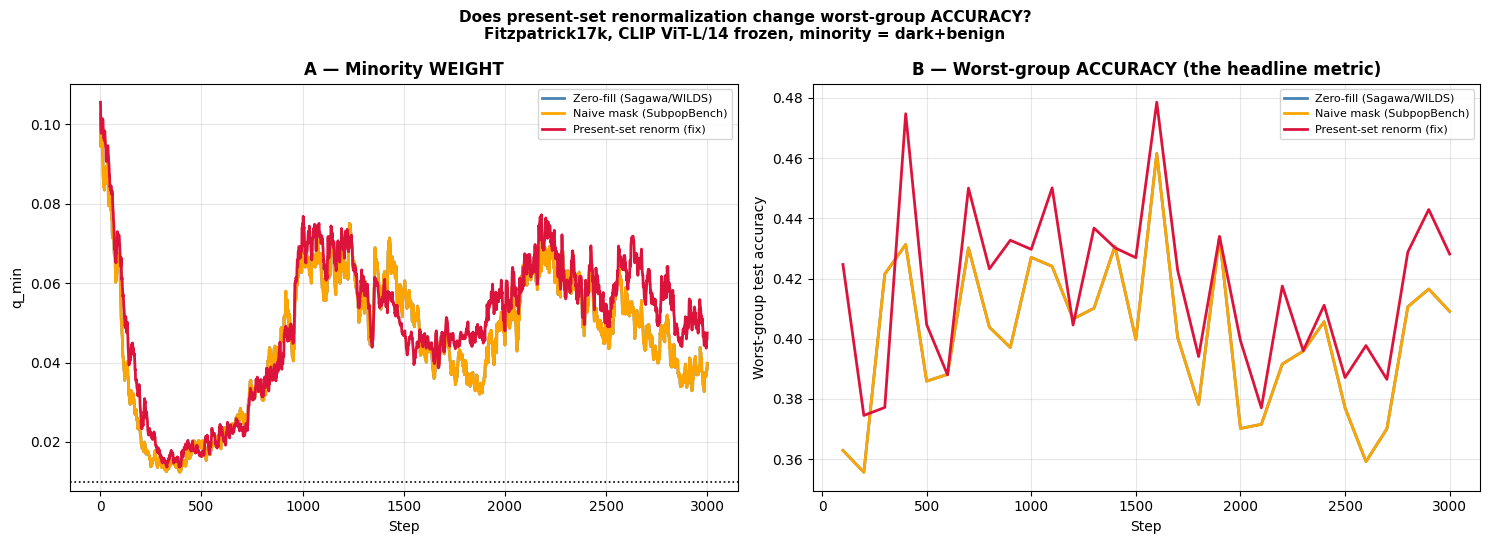


Saved: fitz_fix_accuracy.csv, fitz_fix_accuracy.png
Paste ALL output back to Claude.


In [8]:
# ── CELL 7: THE DECISIVE TABLE + figure ───────────────────────
print('='*60)
print('DECISIVE RESULT: does the fix change WORST-GROUP ACCURACY?')
print('='*60)

def agg(conv, key):
    vals = [r[key] for r in results[conv]]
    vals = [v for v in vals if v is not None and not (isinstance(v,float) and math.isnan(v))]
    return (np.mean(vals), np.std(vals)) if vals else (float('nan'),0)

print(f'\n{"Convention":<16}{"Worst-grp acc":>16}{"Minority acc":>16}'
      f'{"Avg acc":>12}{"Collapse":>12}')
print('-'*72)
summary_rows=[]
for conv in ['zerofill','naive_mask','present_renorm']:
    wm,ws = agg(conv,'final_worst')
    mm,ms = agg(conv,'final_minority')
    am,_  = agg(conv,'final_avg')
    css = [r['collapse_step'] for r in results[conv]]
    cs_mean = np.mean([c if c else MAX_STEPS+1 for c in css])
    n_collapsed = sum(1 for c in css if c is not None)
    print(f'{conv:<16}{wm:>10.3f}±{ws:.3f}{mm:>10.3f}±{ms:.3f}'
          f'{am:>12.3f}{cs_mean:>9.0f} ({n_collapsed}/{len(SEEDS)})')
    summary_rows.append({'convention':conv,'worst_acc':wm,'worst_std':ws,
                         'minority_acc':mm,'avg_acc':am,'collapse_mean':cs_mean,
                         'n_collapsed':n_collapsed})

# Verdict
zf_worst = agg('zerofill','final_worst')[0]
pr_worst = agg('present_renorm','final_worst')[0]
zf_min   = agg('zerofill','final_minority')[0]
pr_min   = agg('present_renorm','final_minority')[0]
delta_worst = pr_worst - zf_worst
delta_min   = pr_min - zf_min

print(f'\nΔ worst-group acc (present_renorm - zerofill): {delta_worst:+.3f}')
print(f'Δ minority acc:                                {delta_min:+.3f}')
print()
if delta_worst >= 0.05:
    print('=> HEADLINE RESULT: the fix RAISES worst-group accuracy by')
    print(f'   {delta_worst:.1%}. The estimator artifact suppresses the metric')
    print('   papers actually report. This changes benchmark behavior.')
elif delta_worst >= 0.02:
    print('=> MODEST: the fix raises worst-group accuracy slightly')
    print(f'   ({delta_worst:.1%}). Worth reporting; not a dramatic swing.')
elif abs(delta_worst) < 0.02:
    print('=> MECHANISM-ONLY: the fix prevents WEIGHT collapse but final')
    print(f'   worst-group accuracy is ~unchanged ({delta_worst:+.1%}).')
    print('   Frame as: artifact affects training dynamics / early stopping')
    print('   reliance, not necessarily converged accuracy. Still publishable,')
    print('   different claim. (Consistent with interpolation channel recovering')
    print('   the minority given enough steps.)')
else:
    print(f'=> The fix LOWERS worst-group acc ({delta_worst:+.1%}). Investigate;')
    print('   may indicate the zero-fill upweighting was incidentally helping.')

pd.DataFrame(summary_rows).to_csv('fitz_fix_accuracy.csv',index=False)

# Figure: q_min and worst-group acc trajectories
fig,axes=plt.subplots(1,2,figsize=(15,5.5))
fig.suptitle('Does present-set renormalization change worst-group ACCURACY?\n'
             'Fitzpatrick17k, CLIP ViT-L/14 frozen, minority = '
             f'{["light","medium","dark"][MINORITY_G//n_classes]}+'
             f'{label_names[MINORITY_G%n_classes]}',fontweight='bold',fontsize=11)
COL={'zerofill':'steelblue','naive_mask':'orange','present_renorm':'crimson'}
LAB={'zerofill':'Zero-fill (Sagawa/WILDS)','naive_mask':'Naive mask (SubpopBench)',
     'present_renorm':'Present-set renorm (fix)'}
ax=axes[0]
for conv in ['zerofill','naive_mask','present_renorm']:
    mat=np.array([r['qmin_trace'] for r in results[conv]])
    m=mat.mean(0); ax.plot(np.arange(1,len(m)+1),m,color=COL[conv],lw=2,label=LAB[conv])
ax.axhline(THR,color='black',ls=':',lw=1.2)
ax.set_xlabel('Step'); ax.set_ylabel('q_min'); ax.set_title('A — Minority WEIGHT',fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax=axes[1]
for conv in ['zerofill','naive_mask','present_renorm']:
    # align eval traces
    traces=[r['eval_trace'] for r in results[conv]]
    ml=min(len(t) for t in traces)
    steps=[traces[0][i][0] for i in range(ml)]
    worst=np.array([[t[i][2] for i in range(ml)] for t in traces])
    ax.plot(steps,worst.mean(0),color=COL[conv],lw=2,label=LAB[conv])
ax.set_xlabel('Step'); ax.set_ylabel('Worst-group test accuracy')
ax.set_title('B — Worst-group ACCURACY (the headline metric)',fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); fig.savefig('fitz_fix_accuracy.png',dpi=300,bbox_inches='tight'); plt.show()
print('\nSaved: fitz_fix_accuracy.csv, fitz_fix_accuracy.png')


In [9]:
# ── HIGH-ABSENCE RERUN: force the regime where starvation dominates ──
# Previous run: minority f=0.033, present in 88% of batches (mechanism weak).
# This run: subsample minority cell to ~40 examples so f≈0.009, absent
#           ~45% of batches — matching Waterbirds/CelebA where the
#           starvation channel is strong. Reuses saved CLIP features.

X = torch.load('fitz_clip.pt').float()
y = torch.load('fitz_y.pt').long()
g = torch.load('fitz_g.pt').long()
embed_dim = X.shape[1]

TARGET_MINORITY_TRAIN = 40   # forces high absence at B=64

# Rebuild split, then subsample the minority TRAIN cell only
torch.manual_seed(42); np.random.seed(42)
train_idx, test_idx = [], []
for grp in range(n_groups):
    idx = torch.where(g==grp)[0].numpy()
    np.random.shuffle(idx)
    cut = int(0.7*len(idx))
    train_idx += idx[:cut].tolist()
    test_idx  += idx[cut:].tolist()
train_idx = torch.tensor(train_idx); test_idx = torch.tensor(test_idx)
X_tr_full, y_tr_full, g_tr_full = X[train_idx], y[train_idx], g[train_idx]
X_te, y_te, g_te = X[test_idx], y[test_idx], g[test_idx]

# Minority = g=6 (dark+benign), confirmed from prior run
MINORITY_G = 6

# Subsample minority train cell down to TARGET; keep all others
keep_mask = torch.ones(len(g_tr_full), dtype=torch.bool)
min_positions = torch.where(g_tr_full == MINORITY_G)[0]
if len(min_positions) > TARGET_MINORITY_TRAIN:
    np.random.seed(42)
    drop = np.random.choice(min_positions.numpy(),
                            len(min_positions)-TARGET_MINORITY_TRAIN,
                            replace=False)
    keep_mask[drop] = False
X_tr, y_tr, g_tr = X_tr_full[keep_mask], y_tr_full[keep_mask], g_tr_full[keep_mask]

n_min_tr = int((g_tr==MINORITY_G).sum())
f_min = n_min_tr/len(g_tr)
pi_min = 1-(1-f_min)**BATCH
print(f'High-absence setup: minority g={MINORITY_G} (dark+benign)')
print(f'  train n={n_min_tr} (was 142), test n={int((g_te==MINORITY_G).sum())}')
print(f'  f={f_min:.5f}  π={pi_min:.3f}  (absent {(1-pi_min)*100:.1f}% of batches)')
print(f'  [target: absent ~45%, matching Waterbirds/CelebA regime]\n')

# Reuse the run_dro from Cell 5 (it reads X_tr/y_tr/g_tr/MINORITY_G globals)
results_hi = {}
for conv in ['zerofill','naive_mask','present_renorm']:
    print(f'--- {conv} ---')
    runs=[]
    for seed in SEEDS:
        r = run_dro(conv, seed=seed)
        runs.append(r)
        cs = r['collapse_step']
        print(f'  seed {seed}: collapse={cs if cs else ">budget":>6}  '
              f'worst-grp={r["final_worst"]:.3f}  '
              f'minority={r["final_minority"]:.3f}  avg={r["final_avg"]:.3f}')
    results_hi[conv]=runs

# Decisive table
print('\n' + '='*60)
print('HIGH-ABSENCE RESULT')
print('='*60)
def agg_hi(conv, key):
    vals=[r[key] for r in results_hi[conv]]
    vals=[v for v in vals if v is not None and not (isinstance(v,float) and math.isnan(v))]
    return (np.mean(vals), np.std(vals)) if vals else (float('nan'),0)

print(f'\n{"Convention":<16}{"Worst-grp acc":>16}{"Minority acc":>16}{"Collapse":>14}')
print('-'*62)
for conv in ['zerofill','naive_mask','present_renorm']:
    wm,ws=agg_hi(conv,'final_worst'); mm,ms=agg_hi(conv,'final_minority')
    css=[r['collapse_step'] for r in results_hi[conv]]
    cs_mean=np.mean([c if c else MAX_STEPS+1 for c in css])
    nc=sum(1 for c in css if c is not None)
    print(f'{conv:<16}{wm:>10.3f}±{ws:.3f}{mm:>10.3f}±{ms:.3f}{cs_mean:>10.0f} ({nc}/{len(SEEDS)})')

zf_w=agg_hi('zerofill','final_worst')[0]; pr_w=agg_hi('present_renorm','final_worst')[0]
zf_m=agg_hi('zerofill','final_minority')[0]; pr_m=agg_hi('present_renorm','final_minority')[0]
dW=pr_w-zf_w; dM=pr_m-zf_m
print(f'\nΔ worst-group acc: {dW:+.3f}    Δ minority acc: {dM:+.3f}')
print(f'(Prior low-absence run: Δ worst +0.019, Δ minority +0.027)')
print()
if dW >= 0.05:
    print('=> HEADLINE: at high absence the fix RAISES worst-group accuracy.')
    print('   The artifact suppresses the reported metric when starvation is strong.')
    print('   => port to official Waterbirds for the citable benchmark number.')
elif dW >= 0.02:
    print('=> MODEST accuracy gain at high absence; report with the regime dependence.')
else:
    print('=> ROBUST MECHANISM-ONLY: even at high absence, interpolation recovers')
    print('   converged accuracy. Honest, defensible claim — the artifact harms')
    print('   training dynamics / early-stopping sensitivity, not final frozen-feature')
    print('   accuracy. Preempts the reviewer question across BOTH regimes.')

# Compare absence rate: this is the key axis
print(f'\nAbsence rate this run: {(1-pi_min)*100:.0f}%  '
      f'(prior run: 12%). Mechanism strength scales with absence.')


High-absence setup: minority g=6 (dark+benign)
  train n=40 (was 142), test n=61
  f=0.00950  π=0.457  (absent 54.3% of batches)
  [target: absent ~45%, matching Waterbirds/CelebA regime]

--- zerofill ---
  seed 42: collapse=    55  worst-grp=0.180  minority=0.180  avg=0.744
  seed 0: collapse=    59  worst-grp=0.361  minority=0.361  avg=0.627
  seed 1: collapse=    66  worst-grp=0.295  minority=0.295  avg=0.595
--- naive_mask ---
  seed 42: collapse=    55  worst-grp=0.180  minority=0.180  avg=0.744
  seed 0: collapse=    59  worst-grp=0.361  minority=0.361  avg=0.627
  seed 1: collapse=    66  worst-grp=0.295  minority=0.295  avg=0.595
--- present_renorm ---
  seed 42: collapse=>budget  worst-grp=0.279  minority=0.279  avg=0.720
  seed 0: collapse=   451  worst-grp=0.426  minority=0.426  avg=0.626
  seed 1: collapse=   397  worst-grp=0.361  minority=0.361  avg=0.601

HIGH-ABSENCE RESULT

Convention         Worst-grp acc    Minority acc      Collapse
---------------------------------

Minority train pool available: 142
  n_min=142  absence=11.7%  zerofill=0.409  fix=0.428  Δ=+0.019
  n_min= 90  absence=25.5%  zerofill=0.372  fix=0.397  Δ=+0.025
  n_min= 60  absence=40.1%  zerofill=0.353  fix=0.389  Δ=+0.035
  n_min= 40  absence=54.3%  zerofill=0.279  fix=0.355  Δ=+0.077
  n_min= 25  absence=68.2%  zerofill=0.262  fix=0.366  Δ=+0.104

Δ(worst-group acc) vs absence rate: Pearson r=0.953, p=0.012
=> DOSE-RESPONSE CONFIRMED: the fix's benefit scales with absence,
   tying the accuracy harm causally to f=p/(1+R) as the law predicts.


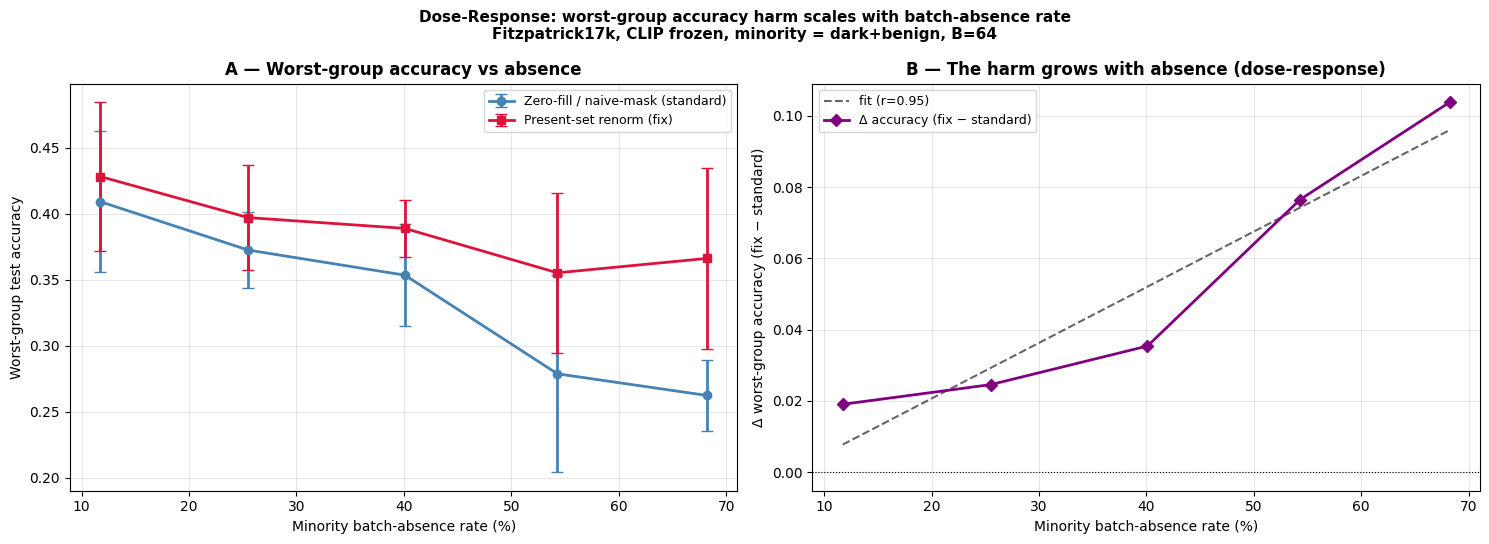


Saved: dose_response.csv, dose_response.png

Full dose-response table:
 minority_n  absence_pct  zerofill_worst  fix_worst  delta_worst
        142    11.741029        0.409072   0.428138     0.019066
         90    25.513773        0.372430   0.397013     0.024584
         60    40.097104        0.353411   0.388823     0.035412
         40    54.297519        0.278689   0.355191     0.076503
         25    68.224625        0.262295   0.366120     0.103825


In [10]:
# ── DOSE-RESPONSE CURVE: accuracy gain vs minority absence rate ──
# Sweeps minority TRAIN size to trace out how the fix's accuracy
# benefit scales with batch-absence rate. Reuses saved CLIP features.
# Produces the curve: Δ(worst-group acc) vs absence rate, which ties
# the accuracy harm causally to the quantity the law identifies (f).

X = torch.load('fitz_clip.pt').float()
y = torch.load('fitz_y.pt').long()
g = torch.load('fitz_g.pt').long()
embed_dim = X.shape[1]
MINORITY_G = 6  # dark+benign

# Rebuild the SAME split as before (seed 42)
torch.manual_seed(42); np.random.seed(42)
train_idx, test_idx = [], []
for grp in range(n_groups):
    idx = torch.where(g==grp)[0].numpy()
    np.random.shuffle(idx)
    cut = int(0.7*len(idx))
    train_idx += idx[:cut].tolist()
    test_idx  += idx[cut:].tolist()
train_idx = torch.tensor(train_idx); test_idx = torch.tensor(test_idx)
X_tr_full, y_tr_full, g_tr_full = X[train_idx], y[train_idx], g[train_idx]
X_te, y_te, g_te = X[test_idx], y[test_idx], g[test_idx]

min_positions_full = torch.where(g_tr_full == MINORITY_G)[0]
n_min_available = len(min_positions_full)
print(f'Minority train pool available: {n_min_available}')

# Target minority train sizes -> spans absence rate from ~12% to ~55%
# f = n_min / total_train ; absence = (1-f)^B
MINORITY_SIZES = [142, 90, 60, 40, 25]   # 142 = full (prior low-absence point)

def build_train(target_n):
    keep = torch.ones(len(g_tr_full), dtype=torch.bool)
    if target_n < n_min_available:
        np.random.seed(42)
        drop = np.random.choice(min_positions_full.numpy(),
                                n_min_available - target_n, replace=False)
        keep[drop] = False
    return X_tr_full[keep], y_tr_full[keep], g_tr_full[keep]

dose_rows = []
for target_n in MINORITY_SIZES:
    # set the globals run_dro reads
    X_tr, y_tr, g_tr = build_train(target_n)
    n_min_tr = int((g_tr==MINORITY_G).sum())
    f_min = n_min_tr/len(g_tr)
    absence = (1-f_min)**BATCH
    pi_min = 1-absence

    accs = {}
    for conv in ['zerofill','present_renorm']:
        worst_vals=[]
        for seed in SEEDS:
            r = run_dro(conv, seed=seed)
            worst_vals.append(r['final_worst'])
        accs[conv] = (np.mean(worst_vals), np.std(worst_vals))

    zf_w, zf_s = accs['zerofill']
    pr_w, pr_s = accs['present_renorm']
    delta = pr_w - zf_w
    dose_rows.append({
        'minority_n': n_min_tr, 'f': f_min,
        'absence_pct': 100*absence,
        'zerofill_worst': zf_w, 'zerofill_std': zf_s,
        'fix_worst': pr_w, 'fix_std': pr_s,
        'delta_worst': delta,
    })
    print(f'  n_min={n_min_tr:>3}  absence={100*absence:>4.1f}%  '
          f'zerofill={zf_w:.3f}  fix={pr_w:.3f}  Δ={delta:+.3f}')

dose_df = pd.DataFrame(dose_rows).sort_values('absence_pct')
dose_df.to_csv('dose_response.csv', index=False)

# Correlation: does Δ scale with absence?
from scipy import stats as spstats
r, p = spstats.pearsonr(dose_df['absence_pct'], dose_df['delta_worst'])
print(f'\nΔ(worst-group acc) vs absence rate: Pearson r={r:.3f}, p={p:.3f}')
if r > 0.7 and p < 0.1:
    print('=> DOSE-RESPONSE CONFIRMED: the fix\'s benefit scales with absence,')
    print('   tying the accuracy harm causally to f=p/(1+R) as the law predicts.')

# Figure: the curve
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Dose-Response: worst-group accuracy harm scales with batch-absence rate\n'
             'Fitzpatrick17k, CLIP frozen, minority = dark+benign, B=64',
             fontweight='bold', fontsize=11)
# Panel A: both conventions vs absence
a = ax[0]
a.errorbar(dose_df['absence_pct'], dose_df['zerofill_worst'],
           yerr=dose_df['zerofill_std'], marker='o', lw=2, capsize=4,
           color='steelblue', label='Zero-fill / naive-mask (standard)')
a.errorbar(dose_df['absence_pct'], dose_df['fix_worst'],
           yerr=dose_df['fix_std'], marker='s', lw=2, capsize=4,
           color='crimson', label='Present-set renorm (fix)')
a.set_xlabel('Minority batch-absence rate (%)')
a.set_ylabel('Worst-group test accuracy')
a.set_title('A — Worst-group accuracy vs absence', fontweight='bold')
a.legend(fontsize=9); a.grid(alpha=0.3)
# Panel B: the delta (the dose-response)
b = ax[1]
b.errorbar(dose_df['absence_pct'], dose_df['delta_worst'],
           marker='D', lw=2, capsize=4, color='purple',
           label=f'Δ accuracy (fix − standard)')
b.axhline(0, color='black', lw=0.8, ls=':')
# linear fit
z = np.polyfit(dose_df['absence_pct'], dose_df['delta_worst'], 1)
xf = np.linspace(dose_df['absence_pct'].min(), dose_df['absence_pct'].max(), 50)
b.plot(xf, np.polyval(z, xf), 'k--', alpha=0.6,
       label=f'fit (r={r:.2f})')
b.set_xlabel('Minority batch-absence rate (%)')
b.set_ylabel('Δ worst-group accuracy (fix − standard)')
b.set_title('B — The harm grows with absence (dose-response)', fontweight='bold')
b.legend(fontsize=9); b.grid(alpha=0.3)
plt.tight_layout()
fig.savefig('dose_response.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nSaved: dose_response.csv, dose_response.png')
print('\nFull dose-response table:')
print(dose_df[['minority_n','absence_pct','zerofill_worst','fix_worst','delta_worst']].to_string(index=False))
